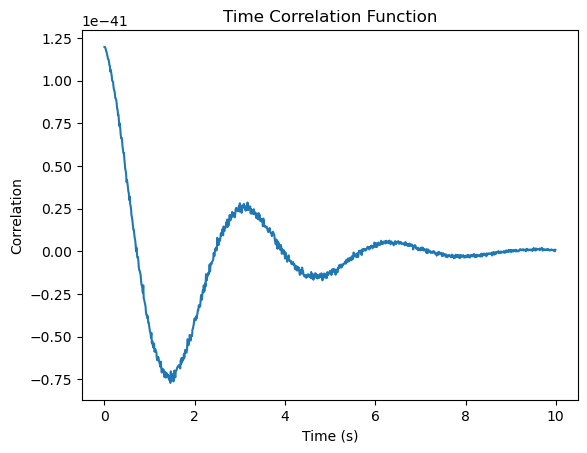

In [ ]:
import numpy as np

class LangevinSystem:
    def __init__(self, dHdq, dHdp, gamma, k_B, T):
        self.dHdq = dHdq
        self.dHdp = dHdp
        self.gamma = gamma
        self.k_B = k_B
        self.T = T

    def step(self, q, p, dt):
        dqdt = self.dHdp(q, p)
        dpdt = -self.dHdq(q, p) - self.gamma * p + np.random.normal(0, np.sqrt(2. * self.gamma * self.k_B * self.T), size=p.shape)

        q_next = q + dqdt * dt
        p_next = p + dpdt * dt
        
        return q_next, p_next
    
def time_correlation(system, A, q0, p0, dt, num_steps, num_samples):
    correlation = np.zeros(num_samples)

    q, p = q0, p0
    A_values = []
    A_values.append(A(q, p))  # Initial value of A  

    for _ in range(num_steps):
        A_values.append(A(q, p))
        q, p = system.step(q, p, dt)

    correlation = np.mean(A_values[-1] * A_values[0])  # Correlation with the initial value

    return correlation

# Example usage:
import matplotlib.pyplot as plt
def example_dHdq(q, p):
    return q  # Example potential energy gradient
def example_dHdp(q, p):
    return p  # Example kinetic energy gradient
def example_A(q, p):
    return q * p  # Example observable

k_B = 1.380649e-23  # Boltzmann constant in J/K
T = 300  # Temperature in Kelvin
def sample_initial_conditions(num_samples):
    q0 = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    p0 = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    return q0, p0

system = LangevinSystem(example_dHdq, example_dHdp, gamma=0.5, k_B=k_B, T=T)
q0, p0 = sample_initial_conditions(100)  # Sample 100 initial conditions
dt = 0.01  # Time step
num_steps = 1000  # Number of steps to simulate
num_samples = 100  # Number of samples for correlation

times = np.arange(0, num_steps*dt, dt)
correlations = [time_correlation(system, example_A, q0, p0, dt, i_steps, num_samples) for i_steps in range(num_steps)]
plt.plot(times, correlations)
plt.title('Time Correlation Function')
plt.xlabel('Time (s)')
plt.ylabel('Correlation')
plt.show()

Integrated correlation (conductivity): -1.0508e-22


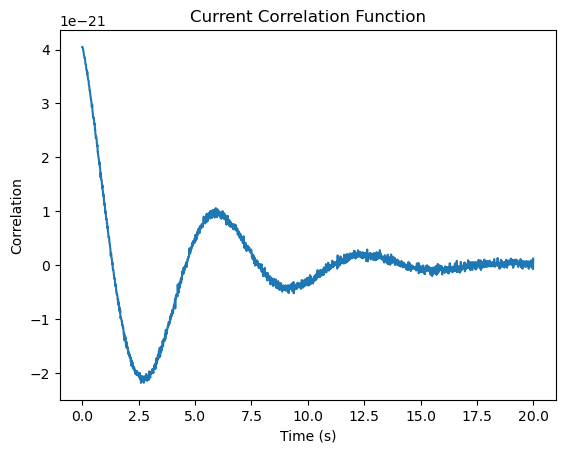

In [ ]:
def current_A(q, p):
    return  p  # J = p

num_steps = 2000  # Number of steps to simulate
num_samples = 50  # Number of samples for correlation

j_correlation = [time_correlation(system, current_A, q0, p0, dt, i_steps, num_samples) for i_steps in range(num_steps)]
integrated_value = np.trapezoid(j_correlation, dx=dt)
print(f"Integrated correlation (conductivity): {integrated_value:.4e}")

times = np.arange(0, num_steps*dt, dt)
plt.plot(times, j_correlation)
plt.title('Current Correlation Function')
plt.xlabel('Time (s)')
plt.ylabel('Correlation')
plt.show()

In [14]:
import numpy as np

def time_evolution_correlation(system, A, q0, p0, dt, num_steps):
    correlation = np.zeros(num_steps)
    q, p = q0, p0
    A_zero = A(q, p)  # Initial value of A
    for i_steps in range(num_steps):
        correlation[i_steps] = np.mean(A(q, p) * A_zero)  # Correlation with the initial value
        q, p = system.step(q, p, dt)
    return correlation

Integrated correlation (conductivity): 8.3900e-21


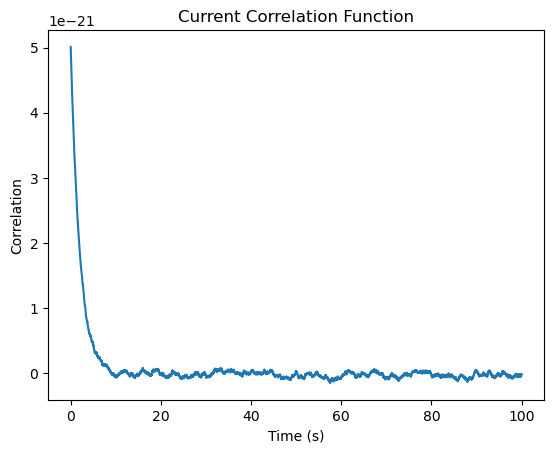

In [ ]:
def current_A(q, p):
    return  p  # J = p

def dHdq(q, p):
    return 0  # potential energy gradient
def dHdp(q, p):
    return p  # kinetic energy gradient

T = 300  # Temperature in Kelvin
k_B = 1.380649e-23  # Boltzmann constant in J/K
gamma = 0.5  # Friction coefficient

def sample_initial_conditions(num_samples):
    q_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    p_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    for _ in range(1000):  # Equilibration steps
        q_0, p_0 = system.step(q_tempo, p_tempo, dt)
    return q_0, p_0

system = LangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=T)
q0, p0 = sample_initial_conditions(100)  # Sample 100 initial conditions
num_steps = 10000  # Number of steps to simulate
num_samples = 200  # Number of samples for correlation

j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)
integrated_value = np.trapezoid(j_correlation, dx=dt)
print(f"Integrated correlation (conductivity): {integrated_value:.4e}")

times = np.arange(0, num_steps*dt, dt)
plt.plot(times, j_correlation)
plt.title('Current Correlation Function')
plt.xlabel('Time (s)')
plt.ylabel('Correlation')
plt.show()

Temperature: 0.0 K, Conductivity: 6.9159e-21
Temperature: 500.0 K, Conductivity: 7.0752e-21


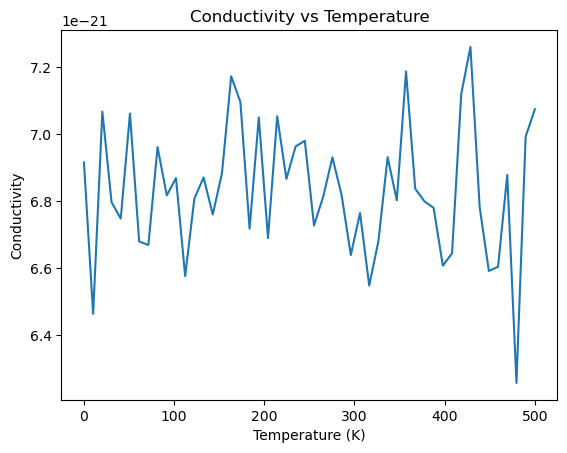

In [34]:
T = np.linspace(0, 500, 50)  # Temperatures from 100K to 500K
conductivities = []
for temp in T:
    system = LangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=temp)
    q0, p0 = sample_initial_conditions(100)  # Sample 100 initial conditions
    j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)
    integrated_value = np.trapezoid(j_correlation, dx=dt)
    conductivities.append(integrated_value)
    if temp % 100 == 0:
        print(f"Temperature: {temp:.1f} K, Conductivity: {integrated_value:.4e}")

plt.plot(T, conductivities)
plt.title('Conductivity vs Temperature')
plt.xlabel('Temperature (K)')
plt.ylabel('Conductivity')
plt.show()

Integrated correlation (conductivity): 8.7199e-22


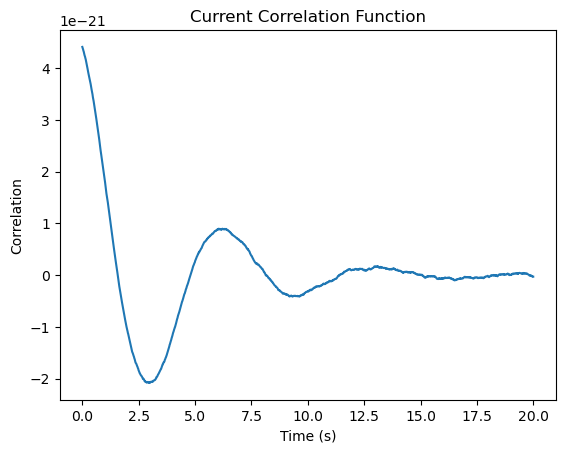

In [48]:
def current_A(q, p):
    return  p  # J = p

def dHdq(q, p):
    return q  # potential energy gradient
def dHdp(q, p):
    return p  # kinetic energy gradient

T = 300  # Temperature in Kelvin
k_B = 1.380649e-23  # Boltzmann constant in J/K
gamma = 0.5  # Friction coefficient

def sample_initial_conditions(num_samples):
    q_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    p_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    for _ in range(1000):  # Equilibration steps
        q_0, p_0 = system.step(q_tempo, p_tempo, dt)
    return q_0, p_0

system = LangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=T)
q0, p0 = sample_initial_conditions(100)  # Sample 100 initial conditions
num_steps = 2000  # Number of steps to simulate
num_samples = 2000  # Number of samples for correlation

j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)
integrated_value = np.trapezoid(j_correlation, dx=dt)
print(f"Integrated correlation (conductivity): {integrated_value:.4e}")

times = np.arange(0, num_steps*dt, dt)
plt.plot(times, j_correlation)
plt.title('Current Correlation Function')
plt.xlabel('Time (s)')
plt.ylabel('Correlation')
plt.show()

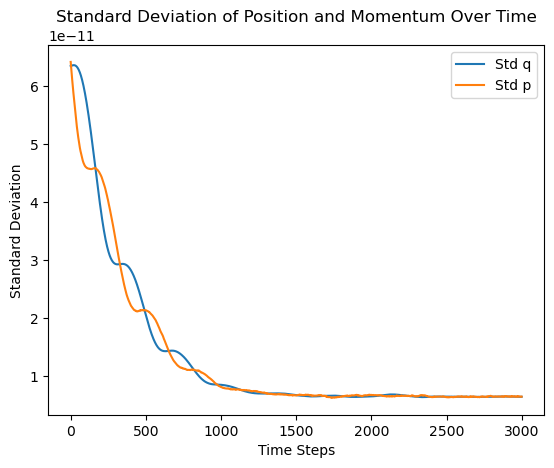

In [49]:
q_std = []
p_std = []
q_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
p_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
for i_steps in range(3000):  # Equilibration steps
    q_std.append(np.std(q_tempo))
    p_std.append(np.std(p_tempo))
    q_tempo, p_tempo = system.step(q_tempo, p_tempo, dt)

plt.plot(q_std, label='Std q')
plt.plot(p_std, label='Std p')
plt.title('Standard Deviation of Position and Momentum Over Time')
plt.xlabel('Time Steps')
plt.ylabel('Standard Deviation')
plt.legend()
plt.show()
